# Notebook to compare analytical Jacobian to equivalent computed through finite differences

In [1]:
import os
import rmgpy.chemkin
import rmgpy.solver
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import cantera as ct

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

# Load mechanism

In [2]:
chemkin = './short-gas.inp.txt'
chemkin_surface = './short-surface.inp.txt'
spec_dict = './species_dictionary.txt'
species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surface)

mech_yaml = './short.yaml'
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

# Define initial conditions

In [3]:
def get_i_thing_rmg(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False


x_O2 = 3e-5  # reasonable match
x_CH4 = 1e-5
T = rmgpy.quantity.Quantity((900, 'K'))
P = rmgpy.quantity.Quantity((1, 'atm'))

surface_volume_ratio = rmgpy.quantity.Quantity((1.0, "m^-1"))  # TODO, try higher surface volume ratios
surface_site_density = rmgpy.quantity.Quantity((surf.site_density, "kmol/m^2"))  # read from Cantera yaml just to be sure these match

termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))


Ar = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[Ar]'), species_list)]
CH4 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='C'), species_list)]
O2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[O][O]'), species_list)]
H2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H][H]'), species_list)]
H2O = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O'), species_list)]
X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='*'), species_list)]

initial_gas_mole_fractions = {O2: x_O2, CH4: x_CH4, Ar: 1.0 - x_O2 - x_CH4}
initial_surface_coverages = {X: 1.0}


sensitive_species = [H2O]
for sp in sensitive_species:
    display(sp)

# Run the SurfaceReactor to the termination time

In [4]:
# Define the surface reactor
reaction_system = rmgpy.solver.surface.SurfaceReactor(
    T,
    P,
    n_sims=1,
    initial_gas_mole_fractions=initial_gas_mole_fractions,
    initial_surface_coverages=initial_surface_coverages,
    surface_volume_ratio=surface_volume_ratio,
    surface_site_density=surface_site_density,
    termination=[termination],
    sensitive_species=sensitive_species,
)

output_directory = './'
os.makedirs(os.path.join(output_directory, 'solver'), exist_ok=True)
reaction_system_index = 0
reaction_system.attach(rmgpy.rmg.listener.SimulationProfileWriter(output_directory, reaction_system_index, species_list))  # to save results

simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings(tol_move_to_core=1e5)  # tol_move_to_core isn't set by default which causes an error
# termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((0.1, 's')))

# Save sensitivities to a CSV file
sens_worksheet = []
for spec in sensitive_species:
    csvfile_path = os.path.join(output_directory, 'solver',
                                'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
    sens_worksheet.append(csvfile_path)


reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
    sensitivity=True,
    sens_worksheet=sens_worksheet,
)

# retrieve the data from the csv
# You could use pandas to get it more directly, but this is fine
simulation_outfile = os.path.join(output_directory, 'solver', f'simulation_1_{len(species_list):d}.csv')
times_rmg, conc_rmg = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_rmg = [d.label for d in conc_rmg]

# Get the analytical Jacobian and compare to finite differences version

In [5]:
# Get analytical Jacobian (cj=0 gives pure df/dn)
t = reaction_system.t
y = reaction_system.y
dydt = reaction_system.dydt

J_analytical = reaction_system.jacobian(t, y, dydt, cj=0.0)

## Jacobian is
$$ J_{is} = \frac{\partial \dot n_i}{\partial n_s} = \frac{\partial }{\partial n_s} \frac{d n_i}{dt}$$

Converting this to a finite difference, we can get:

$$ J_{is, \text{finite difference}} =\frac{\frac{d n_i }{dt}_{|\text{ perturbed}} - \frac{dn_i}{dt}}{\Delta n_s}=  \frac{ \frac{d n_i (n_1, ..., n_s + \Delta n_s,..., n_N)}{dt} - \frac{dn_i (n_1, ..., n_s,..., n_N)}{dt}} {\Delta n_s}$$

We have $\frac{d n_i}{dt}$ stored in our reaction_system object: reaction_system.dydt

We have all the $n_s$ stored in reaction_system.y

So how do we perturb $n_s$ and then recompute $\frac{d n}{dt}$? Use the residual

The residual $r$ is defined as

$$r= f(n, t) - \frac{dn}{dt}=0$$

So we can perturb $n_s$, feed that into the residual function, then subtract off the previous derivative


We call the baseline residual $f_0$
$$f_0= f(n, t) - \frac{dn}{dt}$$

Then the perturbed residual $f_\text{perturbed}$
$$f_\text{perturbed}= f(n_s+\Delta n_s, t) - \frac{dn}{dt}$$

Subtract the two:

$$f_\text{perturbed} - f_0 = \left(f(n_s+\Delta n_s, t) - \frac{dn}{dt}\right) -  \left(f(n, t) - \frac{dn}{dt} \right)$$

$$f_\text{perturbed} - f_0 = f(n_s+\Delta n_s, t)  -  f(n, t) $$

And this is a close approximation of 
$$ f_\text{perturbed} - f_0 = \frac{d n_i (n_1, ..., n_s + \Delta n_s,..., n_N)}{dt} - \frac{dn_i (n_1, ..., n_s,..., n_N)}{dt}$$

Just divide by how much we've perturbed $n_s$ to get the finite differences Jacobian:

$$ J_{is}= \frac{f_\text{perturbed} - f_0}{\Delta n_s}$$

In [6]:
# turn off sensitivity so that it only handles the first n values of y and doesn't get bogged
# down in all the partial derivatives that get stored in y for sensitivity calculations
reaction_system.sensitivity = False

X_index = species_list.index(X)

n = reaction_system.num_core_species
eps_machine = np.sqrt(np.finfo(float).eps)
n_scale = 1e-11

# Get baseline residual f(n)
f0, _ = reaction_system.residual(t, y[:n], dydt[:n])

# Build finite difference Jacobian by column
J_fd = np.zeros((n, n))
for s in range(n):
    y_perturbed = y.copy()
    delta_n_s = eps_machine * max(abs(y[s]), n_scale)  # figure out how much to perturb the value
    y_perturbed[s] += delta_n_s  # add \Delta n_s

    f_perturbed, _ = reaction_system.residual(t, y_perturbed[:n], dydt[:n])
    J_fd[:, s] = (f_perturbed - f0) / delta_n_s



# Show the analytical and finite difference Jacobians side by side
## (on a log scale)

/tmp/ipykernel_522751/1055337641.py:2: RuntimeWarning: divide by zero encountered in log10
  img0 = axs[0].matshow(np.log10(np.abs(J_analytical)))
/tmp/ipykernel_522751/1055337641.py:3: RuntimeWarning: divide by zero encountered in log10
  img1 = axs[1].matshow(np.log10(np.abs(J_fd)))


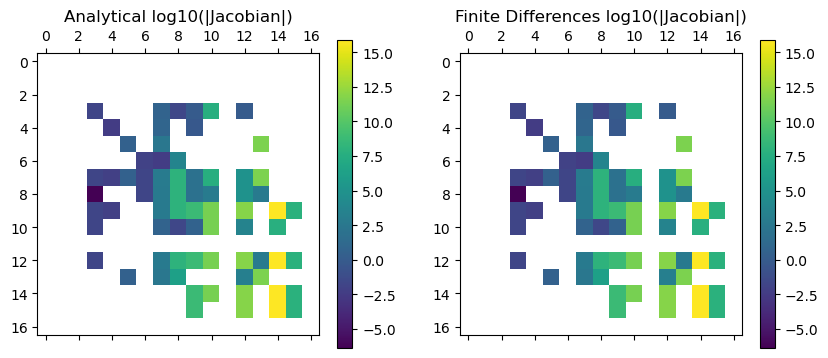

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
img0 = axs[0].matshow(np.log10(np.abs(J_analytical)))
img1 = axs[1].matshow(np.log10(np.abs(J_fd)))

axs[0].set_title('Analytical log10(|Jacobian|)')
axs[1].set_title('Finite Differences log10(|Jacobian|)')
plt.colorbar(img0, ax=axs[0])
plt.colorbar(img1, ax=axs[1])

# Check how close the results actually are

In [8]:
atol = 1e-3
rtol = 1e-2


abs_err = np.abs(J_analytical - J_fd)
scale = np.maximum(np.abs(J_analytical), np.abs(J_fd))
rel_err = np.where(scale > atol, abs_err / scale, 0.0)

max_abs = np.unravel_index(np.argmax(abs_err), abs_err.shape)
max_rel = np.unravel_index(np.argmax(rel_err), rel_err.shape)

print(f"Max absolute error: {abs_err[max_abs]:.3e} at {max_abs}")
print(f"  analytical: {J_analytical[max_abs]:.6e}")
print(f"  FD:         {J_fd[max_abs]:.6e}")
print(f"Max relative error: {rel_err[max_rel]:.3e} at {max_rel}")
print(f"  analytical: {J_analytical[max_rel]:.6e}")
print(f"  FD:         {J_fd[max_rel]:.6e}")

passed = np.all((abs_err < atol) | (rel_err < rtol))
print(f"\nJacobian check {'PASSED' if passed else 'FAILED'}")


Max absolute error: 1.104e+05 at (14, 14)
  analytical: -7.682202e+15
  FD:         -7.682202e+15
Max relative error: 8.839e-03 at (3, 8)
  analytical: 2.359279e-02
  FD:         2.380318e-02

Jacobian check PASSED


/tmp/ipykernel_522751/1192935513.py:7: RuntimeWarning: invalid value encountered in divide
  rel_err = np.where(scale > atol, abs_err / scale, 0.0)


### Highlight all the failures

In [9]:
print(f'i\tj\tJ_Analytical\tJ_finite_diff')
print('------------------------------------------------------')
for i in range(J_fd.shape[0]):
    for j in range(J_fd.shape[1]):
        if not np.isclose(J_analytical[i, j], J_fd[i,j], atol=1e-6, rtol=1e-1):
            print(f'{i}\t{j}\t{J_analytical[i, j]:.3e}\t{J_fd[i, j]:.3e}')

i	j	J_Analytical	J_finite_diff
------------------------------------------------------
